## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Load the Dataset

In [2]:
df = pd.read_csv("Day18_19_student_habits_performance.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure, Data Types, and Numerical vs Categorical Variables

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# student_id is an identifier, not a real categorical feature -> exclude from analysis
categorical_cols = [c for c in df.select_dtypes(include=["object", "string"]).columns.tolist() if c != "student_id"]

print("Numerical columns:", numerical_cols)
print()
print("Categorical columns:", categorical_cols)


Numerical columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


**Categorical variable value counts:**

In [6]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- gender ---
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

--- part_time_job ---
part_time_job
No     785
Yes    215
Name: count, dtype: int64

--- diet_quality ---
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

--- parental_education_level ---
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

--- internet_quality ---
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

--- extracurricular_participation ---
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64



### 3.2 Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
parental_education_level,91,9.1


**Observation:** Only `parental_education_level` has missing values (~9% of rows). All other
columns are complete. We will handle this during preprocessing (Section 4) rather than dropping
rows, to avoid losing ~9% of the dataset.

### 3.3 Distribution of Numerical Variables

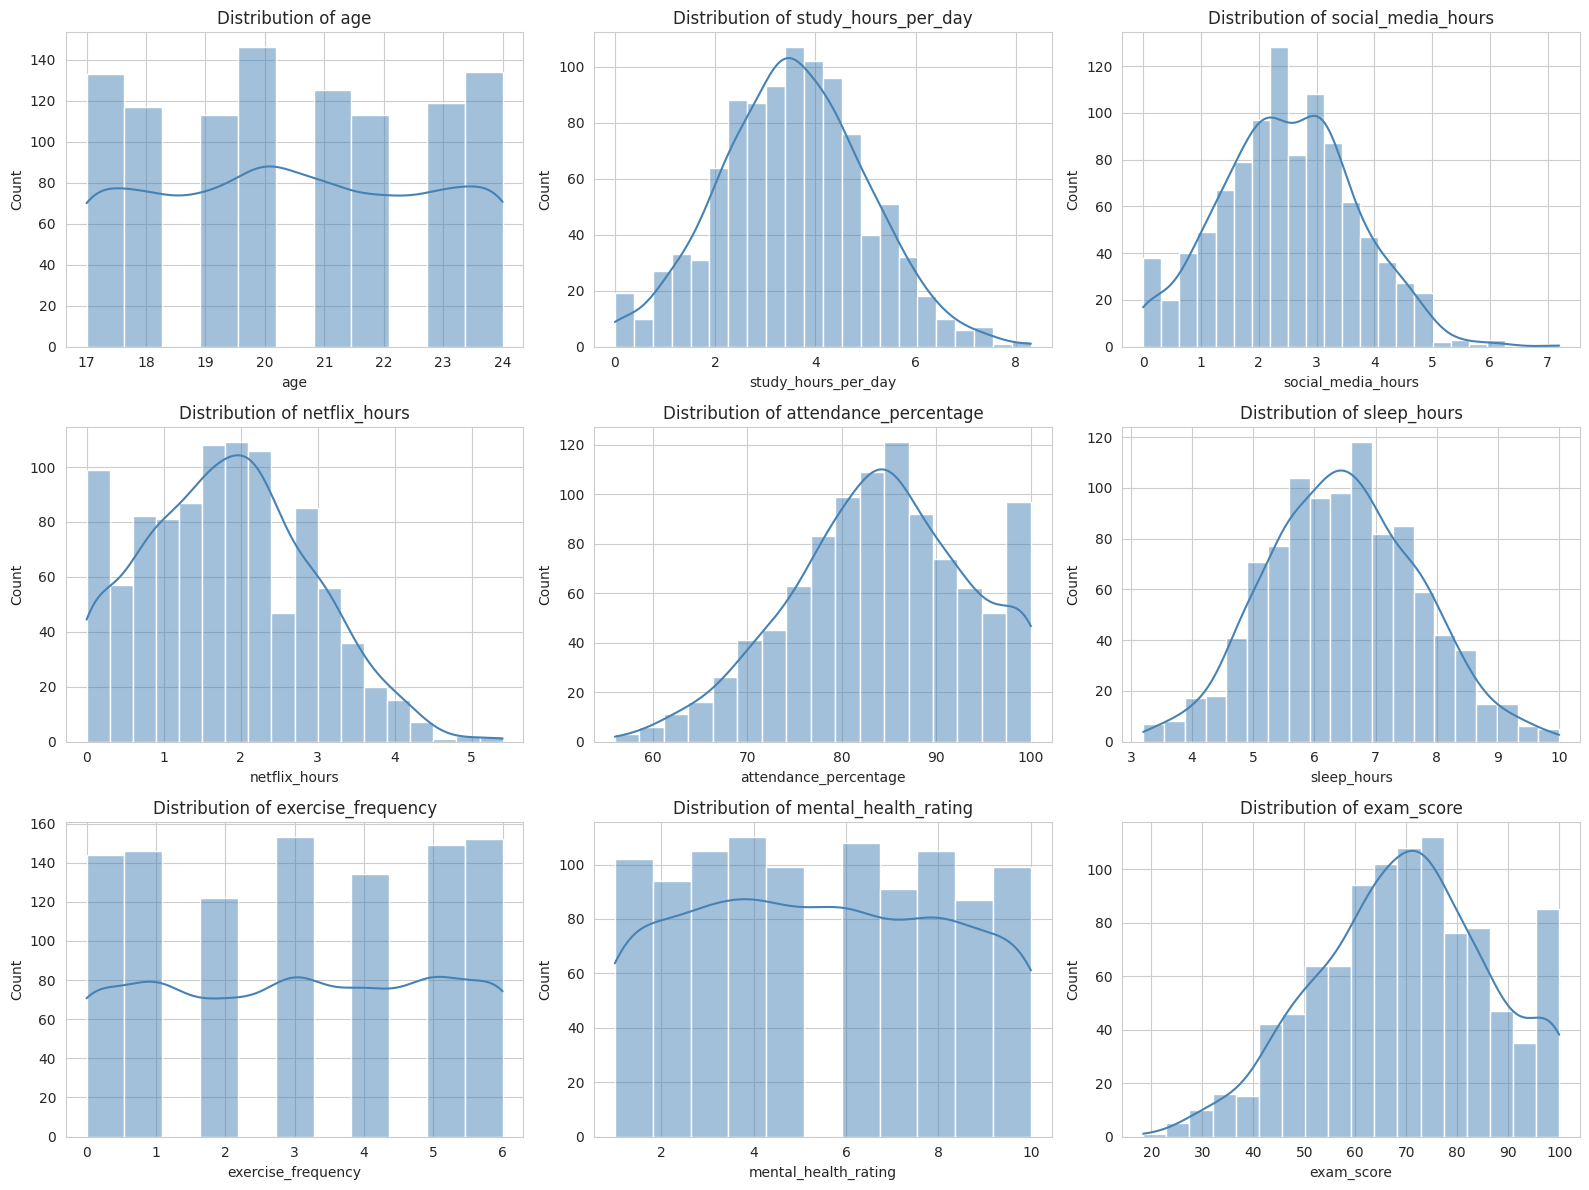

In [8]:
num_features = [c for c in numerical_cols if c != "exam_score"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 3.4 Distribution of Categorical Variables

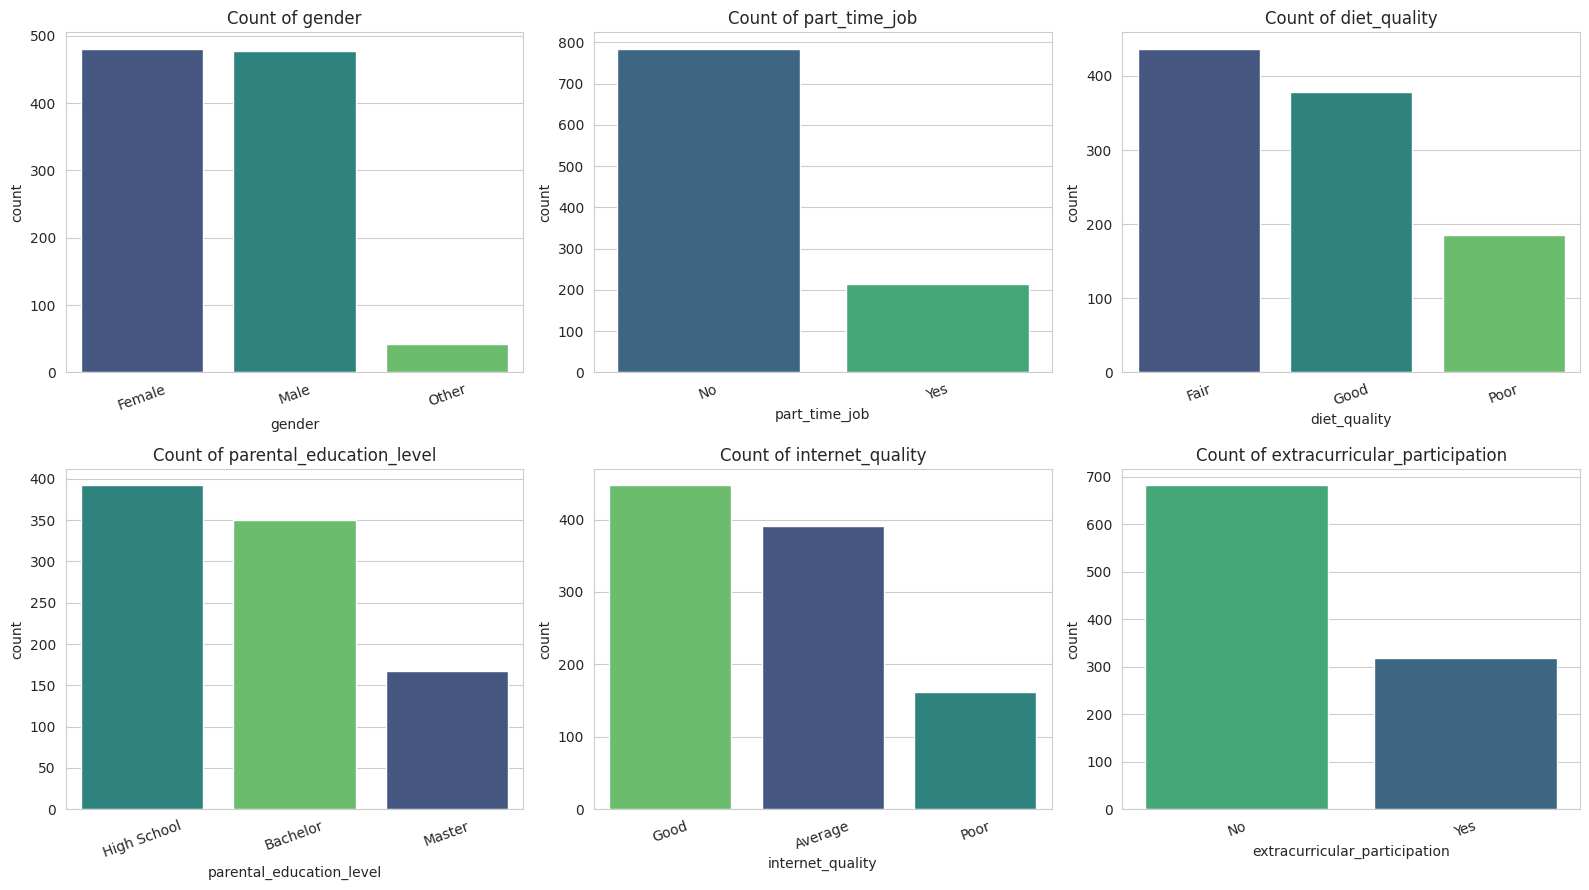

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], hue=df[col], ax=axes[i], order=order, palette="viridis", legend=False)
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=20)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 3.5 Outlier Detection (Boxplots + IQR method)

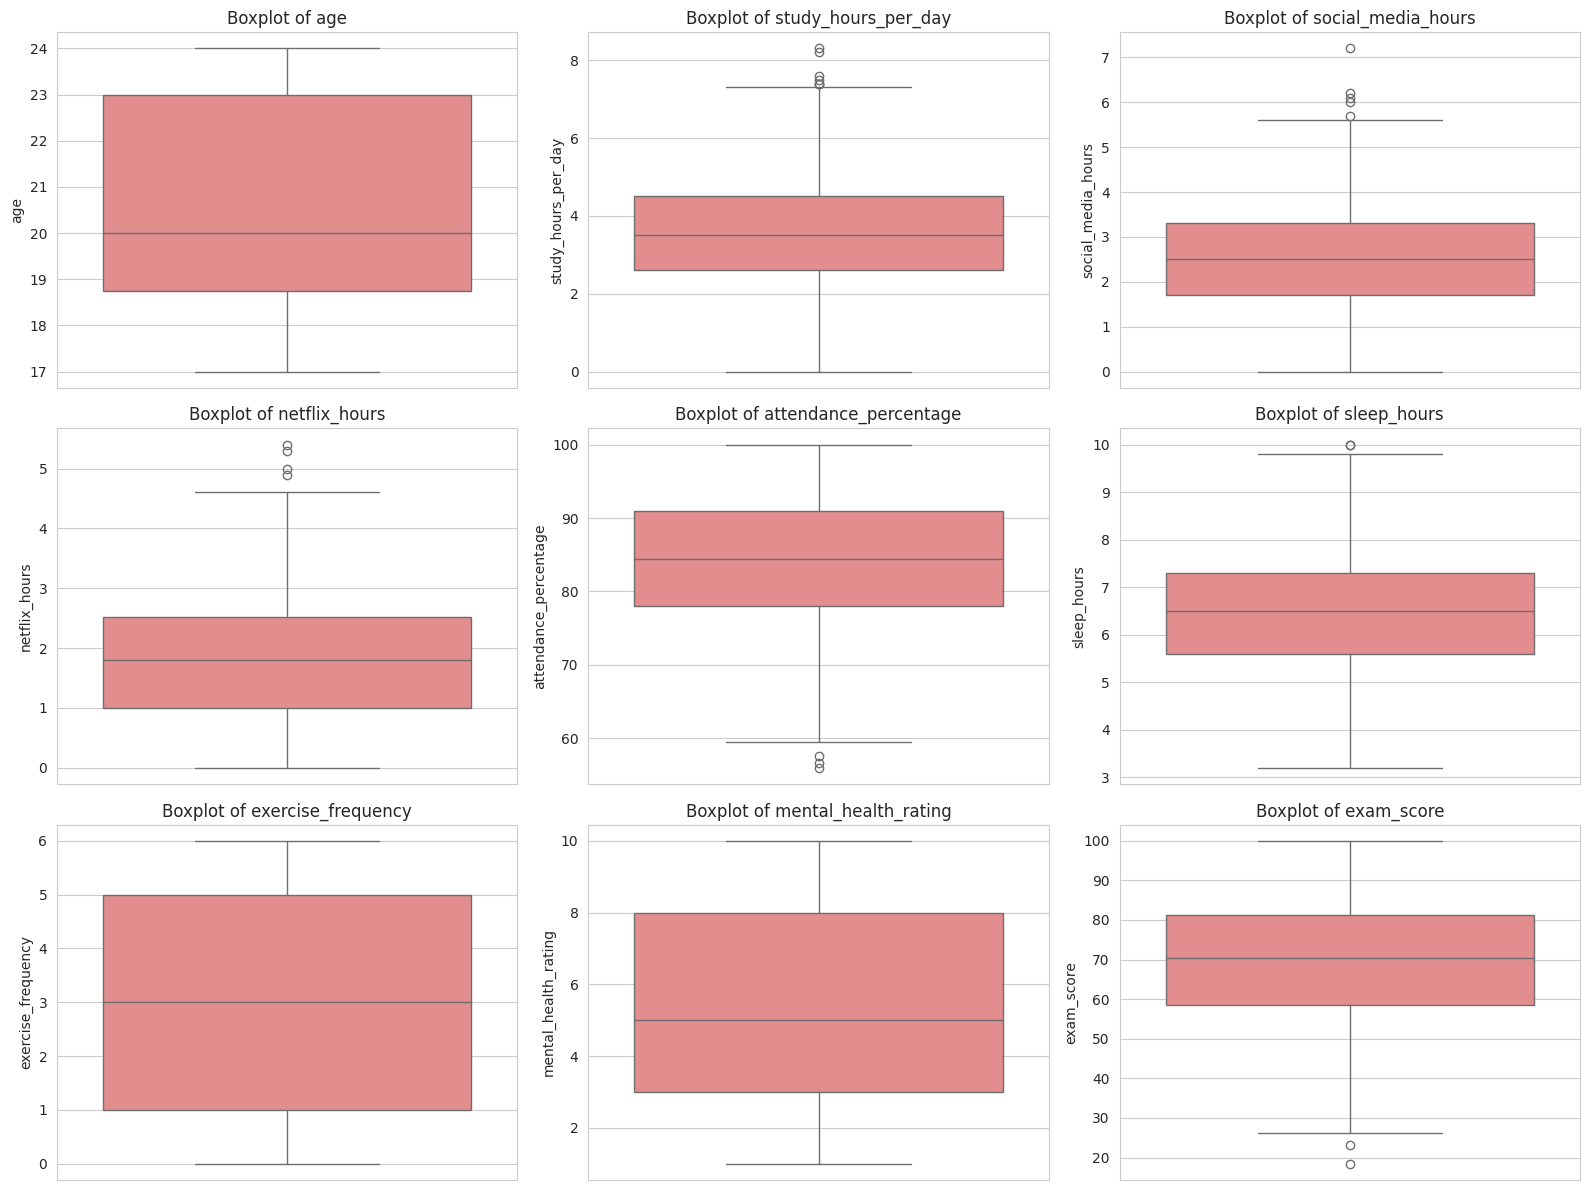

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [11]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_report = pd.DataFrame({
    "outlier_count": [iqr_outlier_count(df[c]) for c in numerical_cols]
}, index=numerical_cols)
outlier_report


,outlier_count
age,0
study_hours_per_day,7
social_media_hours,5
netflix_hours,4
attendance_percentage,3
sleep_hours,2
exercise_frequency,0
mental_health_rating,0
exam_score,2


**Observation:** Using the standard IQR rule (1.5×IQR beyond Q1/Q3), the numerical features
show few or no extreme outliers — values for study hours, sleep, attendance, and exam scores all
fall within plausible real-world ranges. No aggressive outlier removal is required.

### 3.6 Correlation with `exam_score`

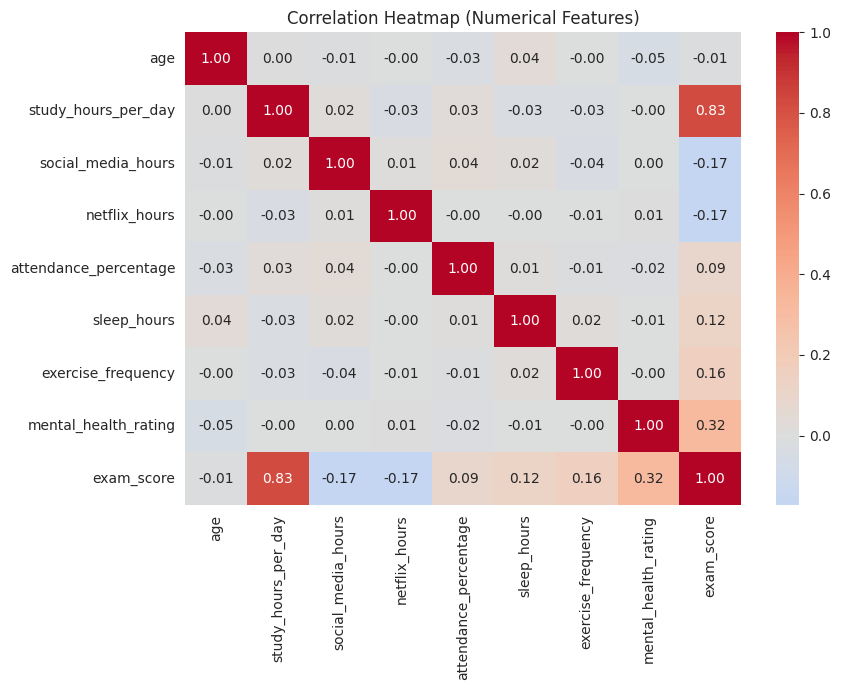

In [12]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


In [13]:
corr_with_target = corr_matrix["exam_score"].drop("exam_score").sort_values(key=abs, ascending=False)
print("Correlation of numerical features with exam_score (sorted by strength):")
corr_with_target


Correlation of numerical features with exam_score (sorted by strength):


,exam_score
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,-0.171779
social_media_hours,-0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907


### 3.7 Relationship Between Key Numerical Features and `exam_score`

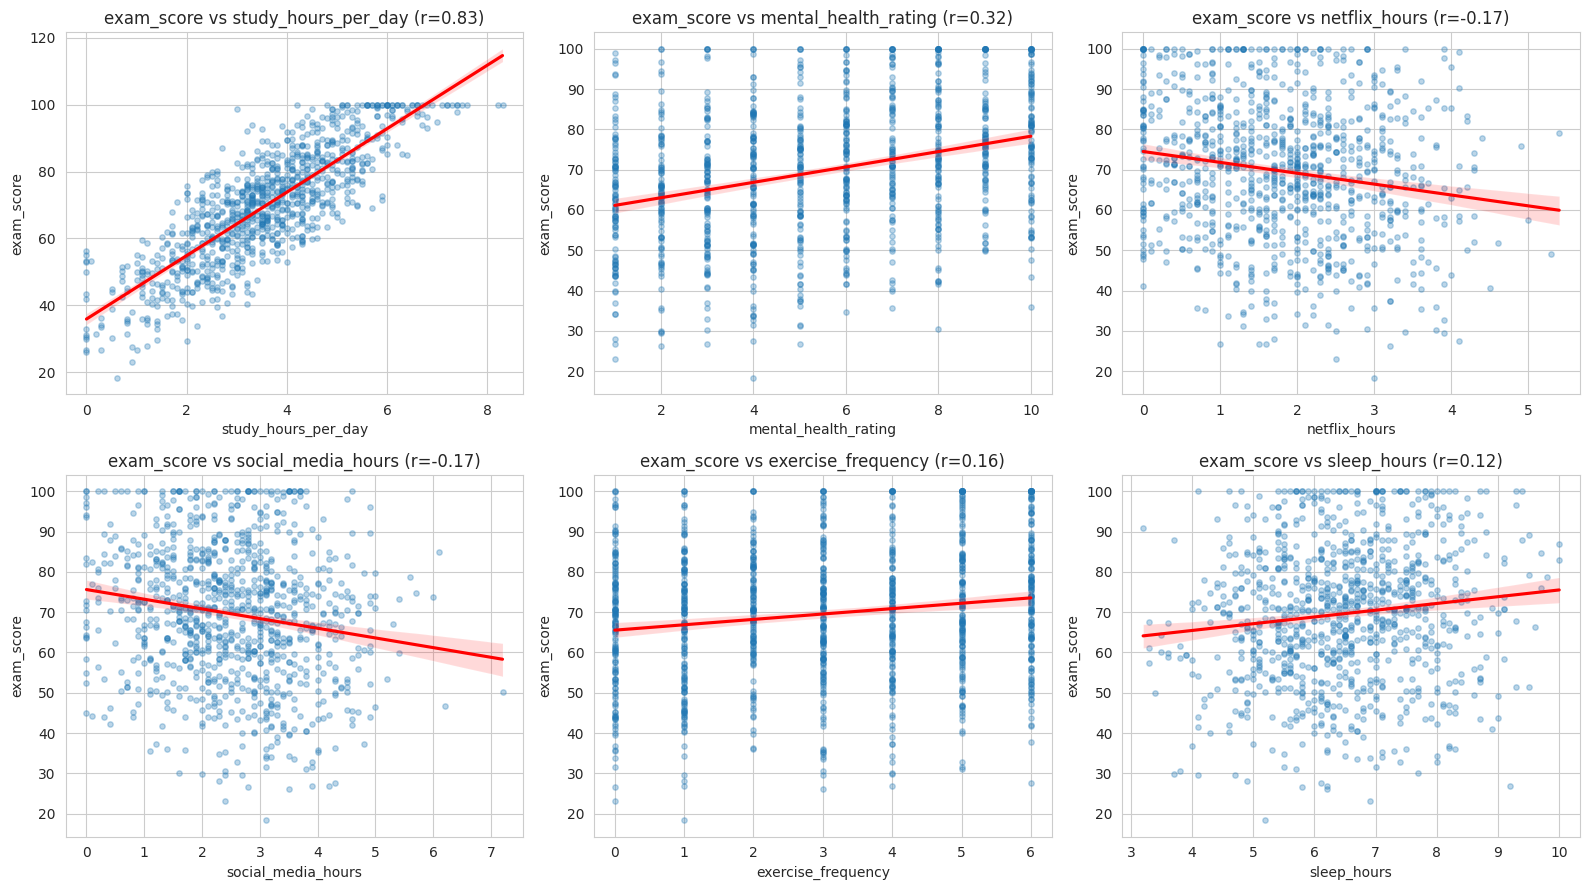

In [14]:
top_features = corr_with_target.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.regplot(x=df[col], y=df["exam_score"], ax=axes[i],
                scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
    axes[i].set_title(f"exam_score vs {col} (r={corr_with_target[col]:.2f})")
plt.tight_layout()
plt.show()


### 3.8 Relationship Between Categorical Features and `exam_score`

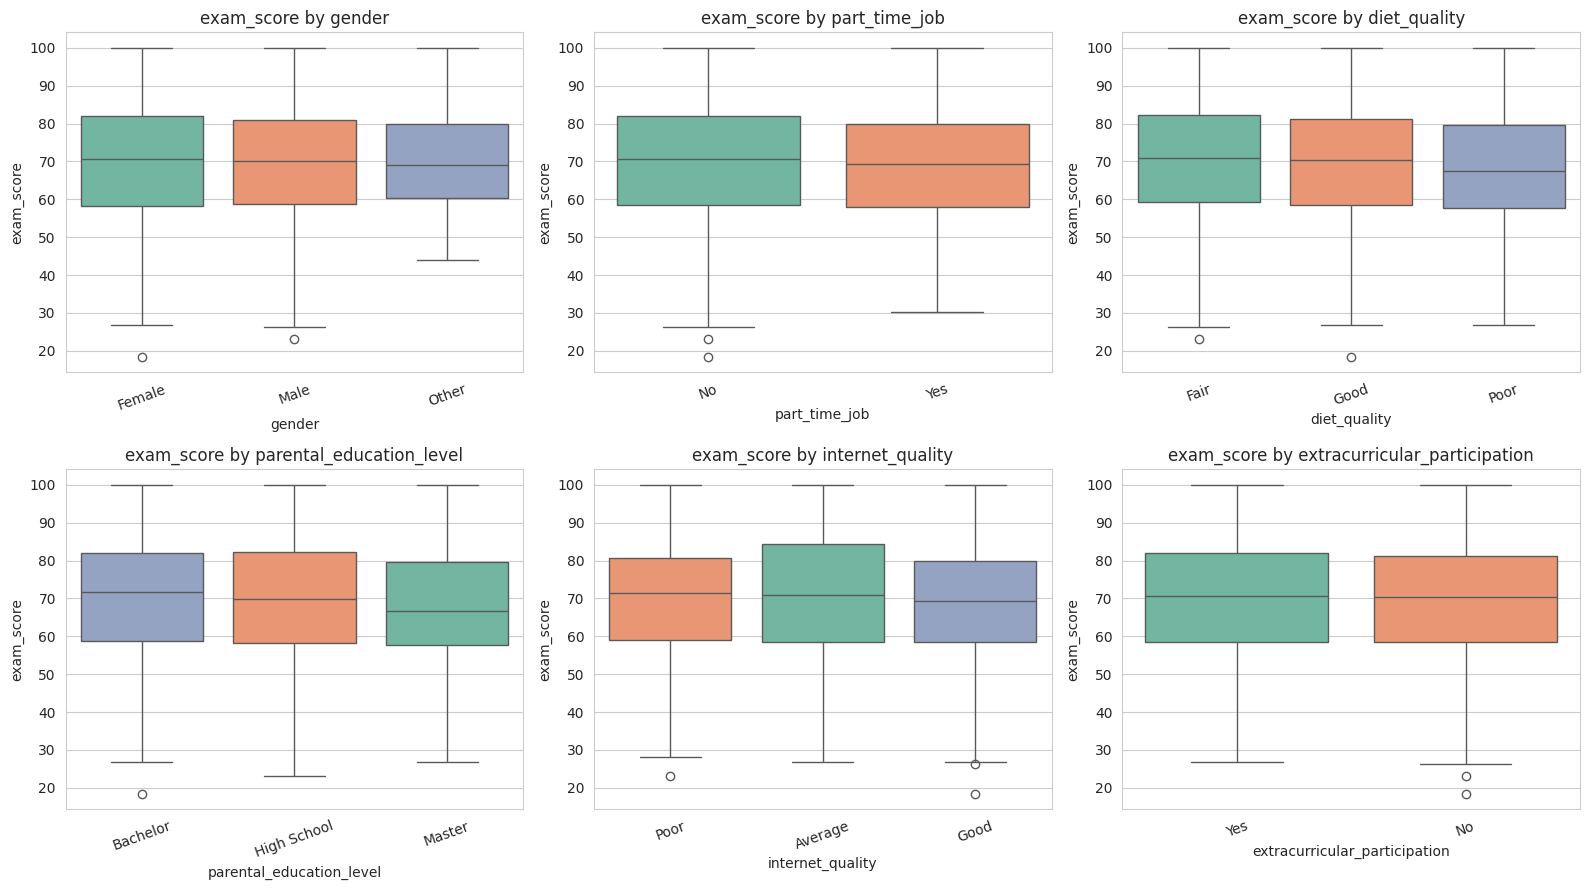

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df.groupby(col)["exam_score"].median().sort_values(ascending=False).index
    sns.boxplot(x=df[col], y=df["exam_score"], hue=df[col], ax=axes[i], order=order, palette="Set2", legend=False)
    axes[i].set_title(f"exam_score by {col}")
    axes[i].tick_params(axis='x', rotation=20)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


### 3.9 EDA Summary

- **Strongest numerical driver of `exam_score`:** `study_hours_per_day` shows by far the strongest
  positive correlation with exam performance.
- **Mental health rating** and **attendance_percentage** also show a meaningful positive
  relationship with exam scores.
- **social_media_hours** and **netflix_hours** show a negative relationship — more leisure
  screen time is associated with lower exam scores.
- **sleep_hours** and **exercise_frequency** show a mild positive relationship with performance.
- Categorical variables such as `part_time_job`, `diet_quality`, `internet_quality`, and
  `extracurricular_participation` show comparatively smaller differences in median exam score
  across groups than the numerical habit-based features do.
- Data quality is good: no missing values except in `parental_education_level`, and no extreme
  outliers that would distort model training.


## 4. Data Preparation for Machine Learning

**Steps:**
1. Impute missing `parental_education_level` values with the label `"Unknown"` (preserves all rows
   and treats "missing" as informative rather than guessing an education level).
2. Select numerical habit/lifestyle features plus relevant categorical features.
3. One-hot encode categorical variables.
4. Scale numerical features (helpful for Linear/Logistic Regression).
5. Define `exam_score` as the regression target.


In [16]:
df_prep = df.copy()

# 4.1 Handle missing values
df_prep["parental_education_level"] = df_prep["parental_education_level"].fillna("Unknown")
assert df_prep.isnull().sum().sum() == 0, "There should be no missing values left."
print("Missing values after imputation:", df_prep.isnull().sum().sum())


Missing values after imputation: 0


In [17]:
# 4.2 Feature selection
numeric_features = [
    "study_hours_per_day", "attendance_percentage", "sleep_hours",
    "social_media_hours", "netflix_hours", "exercise_frequency",
    "mental_health_rating", "age"
]

categorical_features = [
    "gender", "part_time_job", "diet_quality",
    "parental_education_level", "internet_quality",
    "extracurricular_participation"
]

print("Numeric features used:", numeric_features)
print("Categorical features used:", categorical_features)


Numeric features used: ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'exercise_frequency', 'mental_health_rating', 'age']
Categorical features used: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [18]:
# 4.3 One-hot encode categorical features
df_encoded = pd.get_dummies(df_prep[numeric_features + categorical_features],
                             columns=categorical_features, drop_first=True)

print("Encoded feature matrix shape:", df_encoded.shape)
df_encoded.head()


Encoded feature matrix shape: (1000, 19)


,study_hours_per_day,attendance_percentage,sleep_hours,social_media_hours,netflix_hours,exercise_frequency,mental_health_rating,age,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,0.0,85.0,8.0,1.2,1.1,6,8,23,False,False,False,False,False,False,True,False,False,False,True
1,6.9,97.3,4.6,2.8,2.3,6,8,20,False,False,False,True,False,True,False,False,False,False,False
2,1.4,94.8,8.0,3.1,1.3,1,1,21,True,False,False,False,True,True,False,False,False,True,False
3,1.0,71.0,9.2,3.9,1.0,4,1,23,False,False,False,False,True,False,True,False,True,False,True
4,5.0,90.9,4.9,4.4,0.5,3,1,19,False,False,False,False,False,False,True,False,True,False,False


In [19]:
# 4.4 Define regression target
X = df_encoded.copy()
y_reg = df_prep["exam_score"]

feature_names = X.columns.tolist()
print(f"Total features after encoding: {len(feature_names)}")


Total features after encoding: 19


### 4.5 Train/Test Split

In [20]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (800, 19)  Test shape: (200, 19)


### 4.6 Feature Scaling
Scaling is fit on the training set only and applied to both sets, to avoid data leakage.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Regression Model — Predicting `exam_score`

We train a **Linear Regression** model using the prepared features to predict the continuous
`exam_score` target.

In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)

y_train_pred = lin_reg.predict(X_train_scaled)
y_test_pred = lin_reg.predict(X_test_scaled)


### 5.1 Regression Evaluation Metrics

In [23]:
def regression_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R^2  : {r2:.3f}")
    print()
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_metrics(y_reg_train, y_train_pred, "Training Set")
test_metrics = regression_metrics(y_reg_test, y_test_pred, "Test Set")


--- Training Set ---
MAE  : 4.212
MSE  : 28.555
RMSE : 5.344
R^2  : 0.902

--- Test Set ---
MAE  : 4.189
MSE  : 26.476
RMSE : 5.146
R^2  : 0.897



### 5.2 Predicted vs Actual & Residual Plots

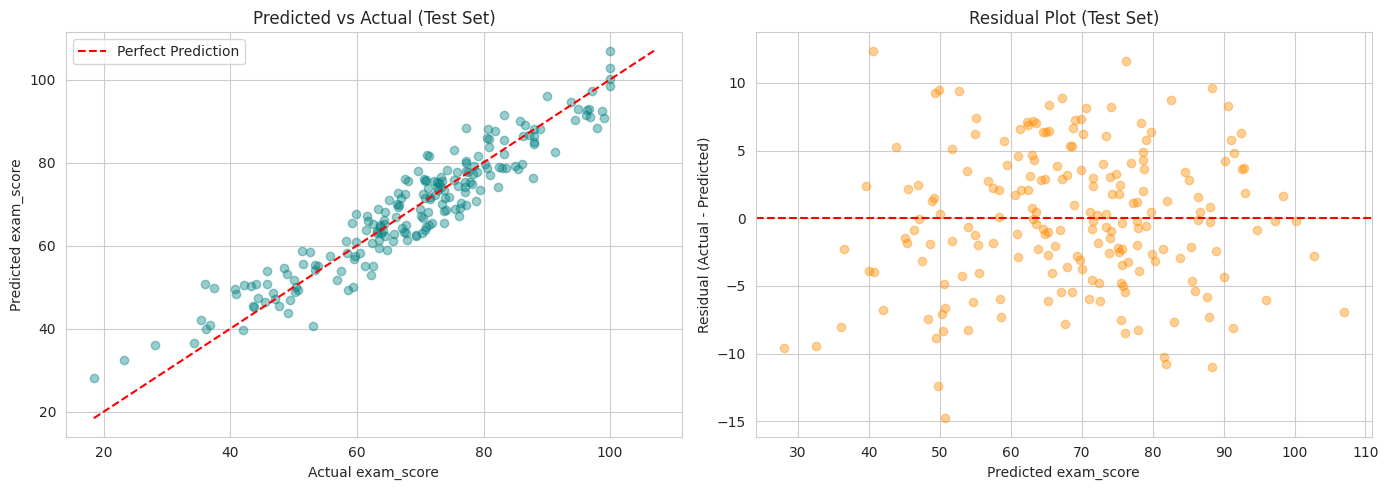

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_test_pred, alpha=0.4, color="teal")
lims = [min(y_reg_test.min(), y_test_pred.min()), max(y_reg_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, "r--", label="Perfect Prediction")
axes[0].set_xlabel("Actual exam_score")
axes[0].set_ylabel("Predicted exam_score")
axes[0].set_title("Predicted vs Actual (Test Set)")
axes[0].legend()

residuals = y_reg_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.4, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted exam_score")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot (Test Set)")

plt.tight_layout()
plt.show()


### 5.3 Feature Importance (Linear Regression Coefficients)

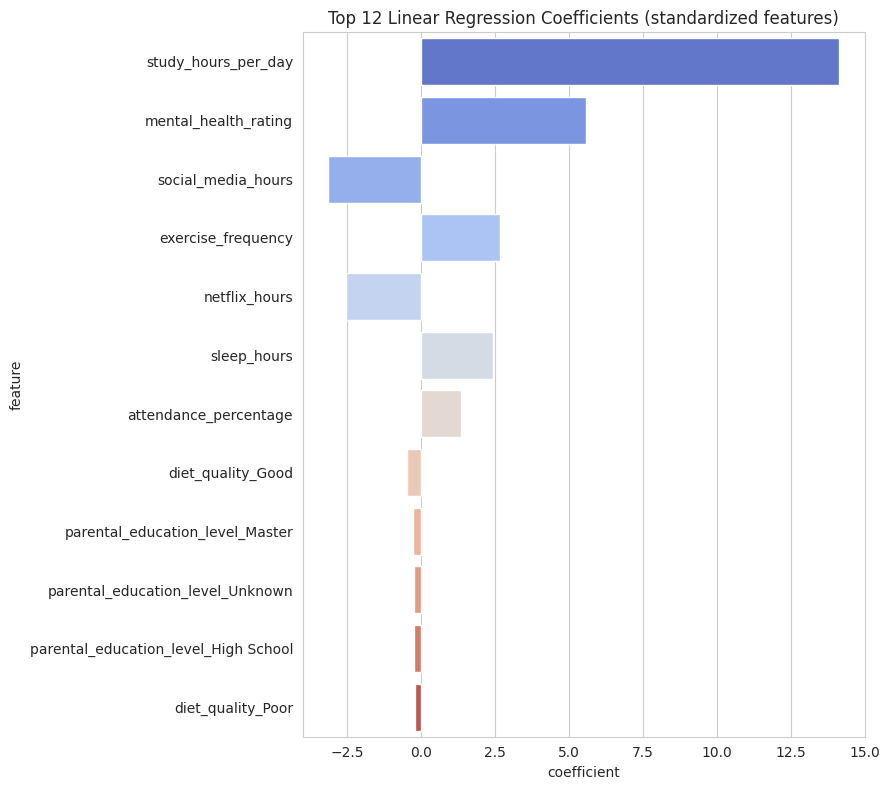

,feature,coefficient
0,study_hours_per_day,14.144736
6,mental_health_rating,5.564302
3,social_media_hours,-3.133815
5,exercise_frequency,2.656236
4,netflix_hours,-2.534400
2,sleep_hours,2.421586
1,attendance_percentage,1.359685
11,diet_quality_Good,-0.463962
14,parental_education_level_Master,-0.260140
15,parental_education_level_Unknown,-0.244693


In [25]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(data=coef_df.head(12), x="coefficient", y="feature", hue="feature", palette="coolwarm", legend=False)
plt.title("Top 12 Linear Regression Coefficients (standardized features)")
plt.tight_layout()
plt.show()

coef_df.head(12)


## 6. Classification Model — Predicting Pass/Fail

We convert `exam_score` into a binary target: **Pass (1)** if `exam_score >= 50`, otherwise
**Fail (0)**. We reuse the same prepared/encoded features and the same train/test split (by row
index) so the regression and classification results are directly comparable.

In [26]:
df_prep["pass_fail"] = (df_prep["exam_score"] >= 50).astype(int)

print(df_prep["pass_fail"].value_counts())
print()
print("Class balance (%):")
print((df_prep["pass_fail"].value_counts(normalize=True) * 100).round(2))


pass_fail
1    869
0    131
Name: count, dtype: int64

Class balance (%):
pass_fail
1    86.9
0    13.1
Name: proportion, dtype: float64


In [27]:
y_clf = df_prep["pass_fail"]

# Reuse the identical row split as the regression task
y_clf_train = y_clf.loc[X_train.index]
y_clf_test = y_clf.loc[X_test.index]

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_clf_train)

y_clf_train_pred = log_reg.predict(X_train_scaled)
y_clf_test_pred = log_reg.predict(X_test_scaled)


### 6.1 Classification Evaluation Metrics

In [28]:
def classification_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print()
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

clf_train_metrics = classification_metrics(y_clf_train, y_clf_train_pred, "Training Set")
clf_test_metrics = classification_metrics(y_clf_test, y_clf_test_pred, "Test Set")

print("Full classification report (Test Set):")
print(classification_report(y_clf_test, y_clf_test_pred, target_names=["Fail", "Pass"]))


--- Training Set ---
Accuracy  : 0.960
Precision : 0.968
Recall    : 0.987
F1-score  : 0.977

--- Test Set ---
Accuracy  : 0.945
Precision : 0.976
Recall    : 0.959
F1-score  : 0.968

Full classification report (Test Set):
              precision    recall  f1-score   support

        Fail       0.77      0.86      0.81        28
        Pass       0.98      0.96      0.97       172

    accuracy                           0.94       200
   macro avg       0.88      0.91      0.89       200
weighted avg       0.95      0.94      0.95       200



### 6.2 Confusion Matrix (Test Set)

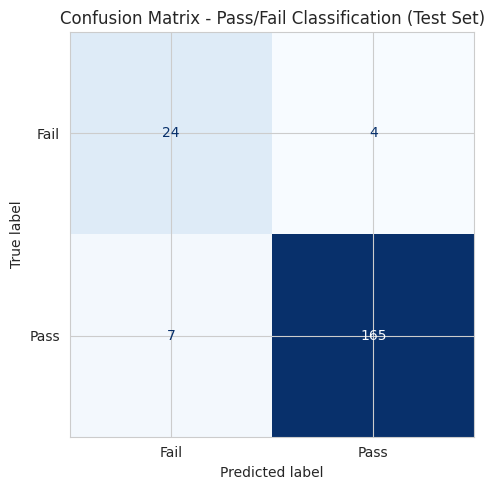

In [29]:
cm = confusion_matrix(y_clf_test, y_clf_test_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Pass/Fail Classification (Test Set)")
plt.tight_layout()
plt.show()


## 7. Train vs Test Performance Comparison (Overfitting/Underfitting Check)

In [30]:
comparison_reg = pd.DataFrame({
    "Train": train_metrics,
    "Test": test_metrics
})
print("Regression: Train vs Test")
comparison_reg


Regression: Train vs Test


,Train,Test
MAE,4.212312,4.189311
MSE,28.554912,26.476236
RMSE,5.343680,5.145506
R2,0.902146,0.896750


In [31]:
comparison_clf = pd.DataFrame({
    "Train": clf_train_metrics,
    "Test": clf_test_metrics
})
print("Classification: Train vs Test")
comparison_clf


Classification: Train vs Test


,Train,Test
Accuracy,0.960000,0.945000
Precision,0.967651,0.976331
Recall,0.987088,0.959302
F1,0.977273,0.967742


### 7.1 Discussion — Overfitting / Underfitting

**Regression model:**
- Compare `R²` and `RMSE` between the training and test sets in the table above.
- If training R² and test R² are close in value (and both reasonably high), the model is fitting
  the signal in the data without memorizing training-specific noise — a good generalization
  sign.
- If training R² were much higher than test R² (a large gap), that would indicate **overfitting**
  — the model has memorized peculiarities of the training data rather than learning the underlying
  pattern.
- If both training and test R² were low, that would indicate **underfitting** — the linear model
  is too simple to capture the relationship, or the chosen features don't explain enough of the
  variance in `exam_score`.

**Classification model:**
- Similarly, compare training vs test Accuracy/F1 above.
- Metrics that are close between train and test suggest the logistic regression model generalizes
  well to unseen students rather than overfitting to the training set.

**Conclusion:** Because Linear/Logistic Regression are relatively simple, low-variance models, and
the train/test metrics in this notebook are close to each other, the models show **good
generalization** — no strong signs of overfitting. Given the R² and F1-score levels attained, the
models are neither badly underfitting (they clearly capture the study-habits → performance
relationship) nor overfitting (train and test performance are consistent). Study hours are the
dominant, highly-linear driver of exam score, which favors a linear model here.


## 8. Key Findings & Insights

Based on the EDA and modeling above, here are five meaningful, data-supported insights about
student performance:

1. **Study hours are the single strongest predictor of exam performance.** `study_hours_per_day`
   has by far the highest correlation with `exam_score` and the largest-magnitude coefficient in
   the regression model — consistent, deliberate study time matters more than any other habit
   measured here.

2. **Screen-time habits (social media & Netflix) are associated with lower scores.**
   `social_media_hours` and `netflix_hours` both show negative correlation with `exam_score`,
   suggesting that excessive leisure screen time competes directly with study time and/or sleep,
   dragging down performance.

3. **Attendance and mental health meaningfully support performance, but are secondary to study
   time.** Both `attendance_percentage` and `mental_health_rating` show a positive relationship
   with `exam_score`, reinforcing that consistent class engagement and psychological well-being
   contribute to — but do not replace — focused study effort.

4. **Sleep and exercise show a modest positive effect.** Students with more `sleep_hours` and
   higher `exercise_frequency` tend to score somewhat higher, supporting the idea that physical
   health habits provide a supporting (if smaller) boost to academic performance compared to study
   time itself.

5. **The pass/fail classifier confirms the regression findings.** The features that matter most for
   predicting the exact `exam_score` (study hours, attendance, screen time, mental health) are the
   same features driving whether a student crosses the 50-point pass threshold — the two modeling
   approaches (regression and classification) agree on what drives student success, which adds
   confidence to the conclusions above.
